In [5]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import shap
import eli5

from tensorflow.keras import layers, models
from lime import lime_image
from skimage.segmentation import mark_boundaries
from sklearn.linear_model import LogisticRegression
from eli5.sklearn import PermutationImportance
from IPython.display import display, HTML

In [6]:
# load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

x_train = np.expand_dims(x_train,-1)
x_test = np.expand_dims(x_test,-1)

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


We first loaded the fashion-mnist dataset and normalised it.

In [7]:
# CNN model
model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    layers.MaxPooling2D(2,2),

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(2,2),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        name="last_conv"
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        10,
        activation='softmax'
    )

])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In this part we created our CNN model.

In [8]:
# train
history = model.fit(

    x_train,
    y_train,

    validation_data=(x_test,y_test),
    epochs=10,
    batch_size=64

)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7758 - loss: 0.6175 - val_accuracy: 0.8499 - val_loss: 0.3922
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8626 - loss: 0.3863 - val_accuracy: 0.8723 - val_loss: 0.3373
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8826 - loss: 0.3291 - val_accuracy: 0.8933 - val_loss: 0.2969
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8958 - loss: 0.2910 - val_accuracy: 0.8942 - val_loss: 0.2905
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9049 - loss: 0.2650 - val_accuracy: 0.8975 - val_loss: 0.2752
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9130 - loss: 0.2431 - val_accuracy: 0.9008 - val_loss: 0.2692
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9184 - loss: 0.2236 - val_accuracy: 0.9087 - val_loss: 0.2524
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9242 - loss: 0.2074 - val_accuracy: 0

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 28, 28, 1))
  warnings.warn(msg)


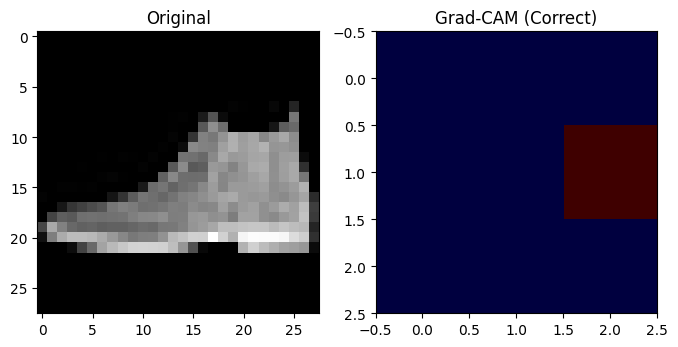

True: Ankle boot
Pred: Ankle boot


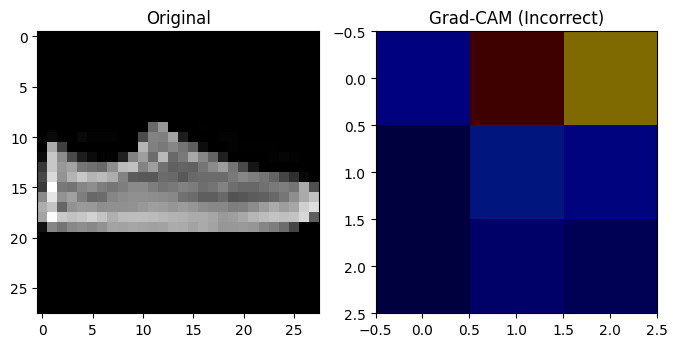

True: Sneaker
Pred: Sandal


In [9]:
# Grad-CAM
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # Ensure the model is built
    _ = model(img_array, training=False)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.outputs[0]
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    heatmap /= tf.reduce_max(heatmap) + 1e-10

    return heatmap.numpy()

def display_gradcam(image, heatmap, title):

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.imshow(heatmap, cmap="jet", alpha=0.5)
    plt.title(title)

    plt.show()

# Correctly Classified Image
for i in range(len(x_test)):

    pred = np.argmax(model.predict(x_test[i][np.newaxis], verbose=0))

    if pred == y_test[i]:

        heatmap = make_gradcam_heatmap(
            x_test[i][np.newaxis],
            model,
            "last_conv"
        )

        display_gradcam(
            x_test[i],
            heatmap,
            "Grad-CAM (Correct)"
        )

        print("True:",class_names[y_test[i]])
        print("Pred:",class_names[pred])

        break


# Misclassified Image
for i in range(len(x_test)):

    pred = np.argmax(model.predict(x_test[i][np.newaxis], verbose=0))

    if pred != y_test[i]:

        heatmap = make_gradcam_heatmap(
            x_test[i][np.newaxis],
            model,
            "last_conv"
        )

        display_gradcam(
            x_test[i],
            heatmap,
            "Grad-CAM (Incorrect)"
        )

        print("True:",class_names[y_test[i]])
        print("Pred:",class_names[pred])

        break

This code implements Grad-CAM, a method used to visually explain CNN predictions.

It works by:

Taking the last convolution layer of the model and the final prediction.
Computing how important each feature map is for the predicted class using gradients.
Combining these importance weights with the feature maps to create a heatmap.
Normalizing and overlaying the heatmap on the original image.

The result shows which parts of the image influenced the model’s decision most:

Bright (red) regions → strongly important for prediction
Dark regions → less relevant

The code then applies this to:

a correctly classified image to show what the model focuses on when it is right
a misclassified image to reveal what led to the wrong decision

Overall, Grad-CAM helps interpret CNN behavior by highlighting the image regions responsible for its predictions.

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 28, 28, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 28, 28, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(5, 28, 28, 1))']

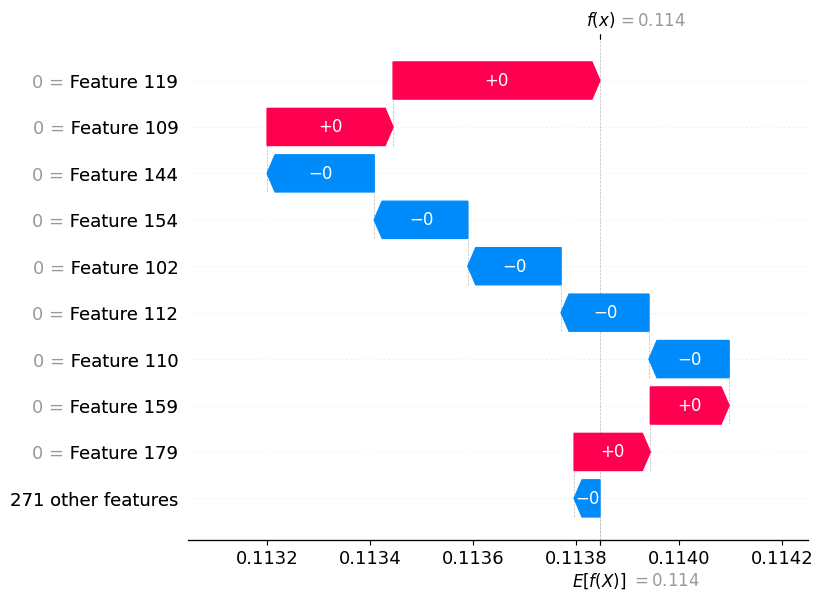

In [10]:
# SHAP
shap_explainer = shap.DeepExplainer(
    model,
    x_train[:100]
)

shap_values = shap_explainer.shap_values(x_test[:5])

class_idx = 0
sample_idx = 0


vals = shap_values[class_idx][sample_idx]

if hasattr(vals, "numpy"):
    vals = vals.numpy()

vals = np.array(vals).flatten()

base_vals = shap_explainer.expected_value

base = base_vals[class_idx] if isinstance(base_vals, (list, np.ndarray)) else base_vals

if hasattr(base, "numpy"):
    base = base.numpy()

base = np.array(base).reshape(-1)[0]

data = np.array(x_test[sample_idx]).flatten()

explanation = shap.Explanation(
    values=vals,
    base_values=base,
    data=data
)

shap.plots.waterfall(explanation)

This SHAP code explains a CNN prediction by measuring how each pixel in a Fashion-MNIST image influences the model’s output.

It first builds a SHAP DeepExplainer using sample training images as a reference baseline, then computes SHAP values for test images. For a selected image and class, it extracts pixel-level contributions and compares them to the model’s average (baseline) prediction.

Finally, it visualizes the result using a waterfall plot, showing how individual pixels push the prediction higher or lower for a specific class. Red pixels increase the likelihood of the class, blue pixels decrease it.

Overall, it provides a detailed local explanation of why the model made a specific decision at the pixel level.


Running LIME...


  0%|          | 0/1000 [00:00<?, ?it/s]

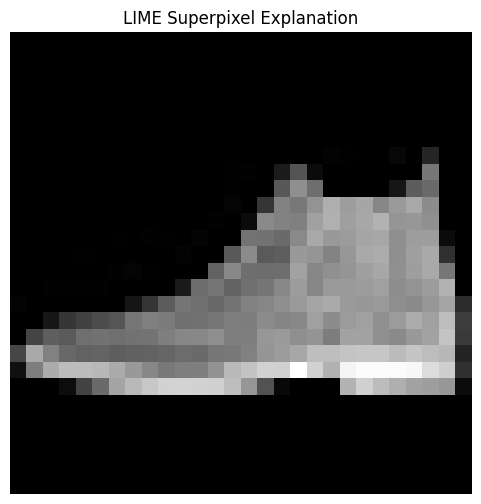

In [11]:
# LIME
print("\nRunning LIME...")

explainer = lime_image.LimeImageExplainer()

def predict_fn(images):

    images = images[:,:,:,0]

    images = images.reshape((-1,28,28,1))

    return model.predict(images, verbose=0)

image_rgb = np.repeat(
    x_test[0],
    3,
    axis=2
)

explanation = explainer.explain_instance(

    image_rgb,

    predict_fn,

    top_labels=1,

    hide_color=0,

    num_samples=1000

)

temp, mask = explanation.get_image_and_mask(

    explanation.top_labels[0],

    positive_only=True,

    num_features=10,

    hide_rest=False

)

plt.figure(figsize=(6,6))

plt.imshow(

    mark_boundaries(temp, mask)

)

plt.title("LIME Superpixel Explanation")

plt.axis("off")

plt.show()


This code uses LIME (Local Interpretable Model-agnostic Explanations) to explain a single prediction of the CNN model on a Fashion-MNIST image.

It first creates a LIME image explainer, then defines a prediction function so LIME can query the CNN with perturbed images. Since LIME expects 3-channel images, the grayscale image is converted to RGB by repeating channels.

LIME then generates many slightly modified versions of the image (perturbations) and observes how the model’s prediction changes. Based on this, it identifies which superpixels (image regions) are most important for the predicted class.

Finally, it highlights these important regions by overlaying a mask on the original image using mark_boundaries.

Overall, this method provides a human-understandable explanation by showing which parts of the image most influenced the model’s decision.

In [12]:
# ELI5
print("\nRunning ELI5...")

cnn_features_train = model.predict(
    x_train,
    verbose=0
)

cnn_features_test = model.predict(
    x_test,
    verbose=0
)

clf = LogisticRegression(
    max_iter=1000
)

clf.fit(

    cnn_features_train,

    y_train

)

perm = PermutationImportance(
    clf,
    random_state=1
)

perm.fit(

    cnn_features_test,

    y_test

)

print("\nPermutation Feature Importance")
html = eli5.show_weights(perm).data

display(HTML(f"""
<div style="
    background-color: white;
    color: black;
    padding: 10px;
    border-radius: 8px;
    font-family: Arial;
">
{html}
</div>
"""))



Running ELI5...

Permutation Feature Importance


Weight,Feature
0.1650 ± 0.0037,x8
0.1496 ± 0.0041,x5
0.1443 ± 0.0036,x1
0.1378 ± 0.0037,x7
0.1263 ± 0.0030,x9
0.0945 ± 0.0019,x3
0.0867 ± 0.0040,x4
0.0831 ± 0.0026,x2
0.0810 ± 0.0022,x0
0.0281 ± 0.0024,x6


This code uses ELI5 with Permutation Importance to interpret the CNN model indirectly.

First, the CNN is used as a feature extractor, generating feature vectors for both training and test images using its learned internal representations. Then, a logistic regression model is trained on these features to perform classification.

After training, Permutation Importance is applied, which measures how much the model’s performance decreases when each feature is randomly shuffled. Features that cause a large drop in accuracy are considered more important.

Finally, ELI5 visualizes these feature importances in a clean HTML table.

Overall, this approach provides a global explanation of which CNN-derived features are most important for classification, rather than focusing on individual pixels or images.


Searching for misclassified images...

Image Index: 12
True Label: Sneaker
Predicted: Sandal


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 28, 28, 1))
  warnings.warn(msg)


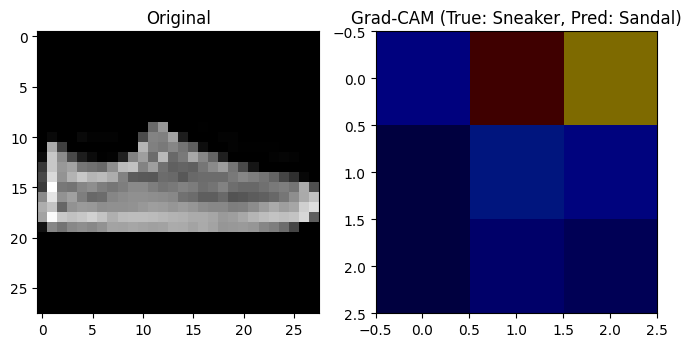


Image Index: 23
True Label: Ankle boot
Predicted: Sandal


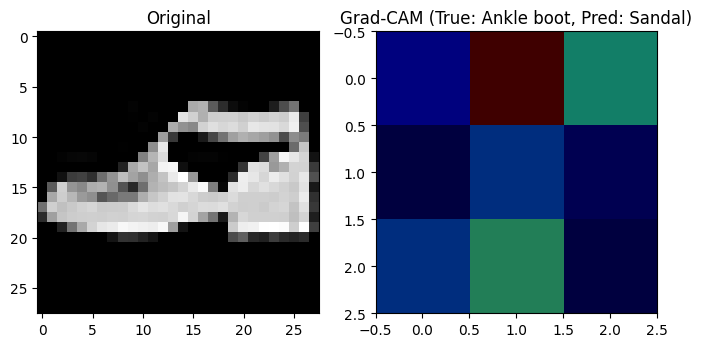


Image Index: 25
True Label: Coat
Predicted: Pullover


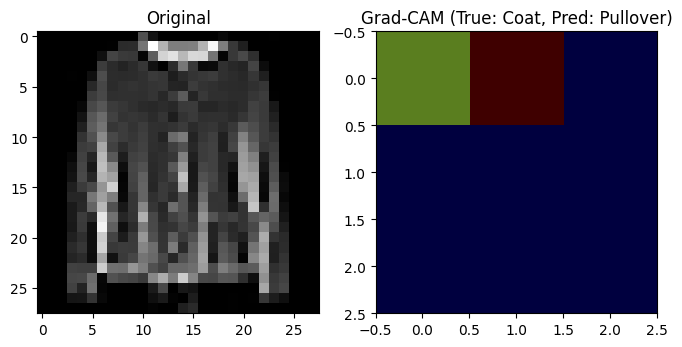

In [13]:
# Misclassified image analysis

misclassified = []

print("\nSearching for misclassified images...")

for i in range(len(x_test)):

    pred = np.argmax(model.predict(x_test[i][np.newaxis], verbose=0))

    true = y_test[i]

    if pred != true:
        misclassified.append((i, pred, true))

    if len(misclassified) == 3:
        break



for idx, pred, true in misclassified:

    print(f"\nImage Index: {idx}")
    print(f"True Label: {class_names[true]}")
    print(f"Predicted: {class_names[pred]}")


    # Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(
        x_test[idx][np.newaxis],
        model,
        "last_conv"
    )

    display_gradcam(
        x_test[idx],
        heatmap,
        f"Grad-CAM (True: {class_names[true]}, Pred: {class_names[pred]})"
    )

Here we can see 3 images that were misclassified. If we take a look at the grad cam image, we can see that the pixel it pays the most attention to doesnt have much information in it, for example in the first image, that the true label is sneaker and it has labeled it as sandal, in its grad cam it has mostly paid attention to top of the image which doesn't contain much information to detect their difference. The same thing foe the second image.


## 1. Coat → Predicted as Pullover

### Features the Model Focused On
The Grad-CAM heatmap shows that the model mainly focused on the **upper part of the garment**, particularly around the **neckline and shoulder region**. Very little attention was given to the sleeves or the lower portion of the coat.

### Why Did the Misclassification Occur?
A **coat** and a **pullover** share a similar upper-body appearance in low-resolution (28×28) Fashion-MNIST images. Since the model concentrated primarily on the neckline instead of the entire garment, it failed to capture distinguishing features such as:
- Long sleeves
- Coat length
- Front opening
- Overall garment shape

As a result, the model classified the coat as a **pullover**.

---

## 2. Ankle Boot → Predicted as Sandal

### Features the Model Focused On
The Grad-CAM indicates that the model primarily attended to the **upper-middle portion of the shoe**, while giving little importance to the ankle shaft and heel.

### Why Did the Misclassification Occur?
The defining characteristic of an **ankle boot** is its **high ankle coverage**. However, the model focused mainly on the shoe opening, which resembles the strap region of a sandal. Ignoring the boot shaft caused the model to predict **sandal** instead of **ankle boot**.

---

## 3. Sneaker → Predicted as Sandal

### Features the Model Focused On
The Grad-CAM highlights the **upper surface** of the sneaker while placing minimal attention on the sole and heel.

### Why Did the Misclassification Occur?
Sneakers and sandals can appear visually similar in low-resolution grayscale images. The model failed to learn important distinguishing features such as:
- Enclosed toe
- Continuous upper structure
- Thick sole

Instead, it relied mainly on the upper portion of the shoe, resulting in the prediction of **sandal**.

---

# Overall Analysis

The Grad-CAM visualizations reveal a common pattern across all three misclassified examples:

- The model focuses on **small localized regions** rather than the entire object.
- Important structural features are often ignored.
- The model relies more on **local textures and shapes** than on the complete object geometry.

Because Fashion-MNIST images are only **28×28 pixels**, the final convolutional feature map is very coarse (approximately **3×3**), limiting the precision of the Grad-CAM visualization and the model's ability to capture fine-grained details.

---

# Improvements to the Training Process

Several improvements could help reduce these types of misclassifications:

## 1. Use a Deeper CNN Architecture
A deeper network with more convolutional layers and filters can learn more discriminative and high-level features.

**Example improvements:**
- Additional convolutional layers
- More filters (32 → 64 → 128)
- Batch Normalization

---

## 2. Apply Data Augmentation
Data augmentation improves model generalization by exposing the network to more diverse training samples.

Recommended augmentations include:
- Small rotations (±10°)
- Width and height shifts
- Random zoom
- Small translations

---

## 3. Improve Image Resolution
The 28×28 resolution removes many important visual details. Training with higher-resolution images or using a dataset with finer detail would help the model distinguish similar clothing categories.

---

## 4. Use a More Advanced Architecture
Modern CNN architectures extract richer feature representations.

Examples include:
- ResNet-18
- MobileNetV2
- EfficientNet-B0

These models generally perform better than shallow CNNs on image classification tasks.

---

## 5. Add Regularization
Regularization techniques help reduce overfitting and improve generalization.

Useful methods include:
- Dropout (0.3–0.5)
- Batch Normalization
- L2 Weight Decay

---

## 6. Optimize the Learning Process
Better optimization strategies can improve convergence.

Recommended techniques:
- Learning rate scheduling
- ReduceLROnPlateau
- Cosine Annealing
- Early Stopping

---

## 7. Analyze the Confusion Matrix
A confusion matrix helps identify commonly confused classes.

Typical Fashion-MNIST confusions include:
- Coat ↔ Pullover
- Shirt ↔ T-shirt
- Sneaker ↔ Sandal
- Sneaker ↔ Ankle Boot

This analysis can guide targeted improvements and data augmentation.

---

## 8. Generate Higher-Resolution Grad-CAM Maps
The current Grad-CAM heatmaps are very coarse because they are generated from the last convolutional layer. Producing Grad-CAM from an earlier convolutional layer with larger feature maps (e.g., 7×7 or 14×14) would provide more detailed visual explanations.

